# Classification — Error Analysis

Deep-dive into where the classification model works well and where it struggles.

**Input:** `data/processed/ev_features.parquet`, `results/iteration_4/best_classifier.pkl`, `results/iteration_3/best_model.pkl`

### Sections
1. Regression → Classification motivation
2. Overfitting check
3. Confusion matrix analysis
4. Per-class precision / recall / F1
5. Error by hour of day
6. Error by day of week
7. Misclassification analysis
8. Confidence analysis
9. Classification vs regression comparison
10. Key takeaways

## 0. Setup & Load

In [1]:
import joblib
import warnings
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
sns.set_style('whitegrid')

# --- Find project root ---
current = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [current, *current.parents]:
    if (candidate / 'data' / 'raw').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not find the project root containing data/raw')

RESULTS_DIR = PROJECT_ROOT / 'results' / 'iteration_4'

# --- Class definitions (same as notebook 08) ---
CLASS_BINS   = [0, 0.1, 5, 20, float('inf')]
CLASS_LABELS = ['Idle', 'Low', 'Medium', 'High']

# --- Load data ---
df = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'ev_features.parquet')

df['demand_level'] = pd.cut(
    df['target'], bins=CLASS_BINS, labels=CLASS_LABELS, right=False
).cat.codes.astype('int8')

SPLIT_DATE = pd.Timestamp('2022-07-01')
train = df[df['timestamp_hour'] < SPLIT_DATE]
test  = df[df['timestamp_hour'] >= SPLIT_DATE]

EXCLUDE = ['customer_id', 'timestamp_hour', 'target', 'year', 'demand_level']
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

X_train, y_train = train[FEATURE_COLS], train['demand_level']
X_test,  y_test  = test[FEATURE_COLS],  test['demand_level']

# --- Load best classifier ---
clf = joblib.load(RESULTS_DIR / 'best_classifier.pkl')

# --- Predict ---
y_pred_train = clf.predict(X_train)
y_pred_test  = clf.predict(X_test)
y_proba_test = clf.predict_proba(X_test)

print(f'Model: {type(clf).__name__}')
print(f'Train: {len(X_train):,} rows | Test: {len(X_test):,} rows')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}')
print(f'Test F1 (macro): {f1_score(y_test, y_pred_test, average="macro"):.4f}')

Model: LGBMClassifier
Train: 4,712,026 rows | Test: 2,517,063 rows
Test Accuracy: 0.8082
Test F1 (macro): 0.6697


## 1. Regression → Classification Motivation

The regression model (R² = 0.514) captured *when* charging occurs but struggled with *how much*.
These sample station plots show the regression predictions tracking the timing of demand spikes
but consistently undershooting their magnitude — motivating the reframing to demand-level classification.

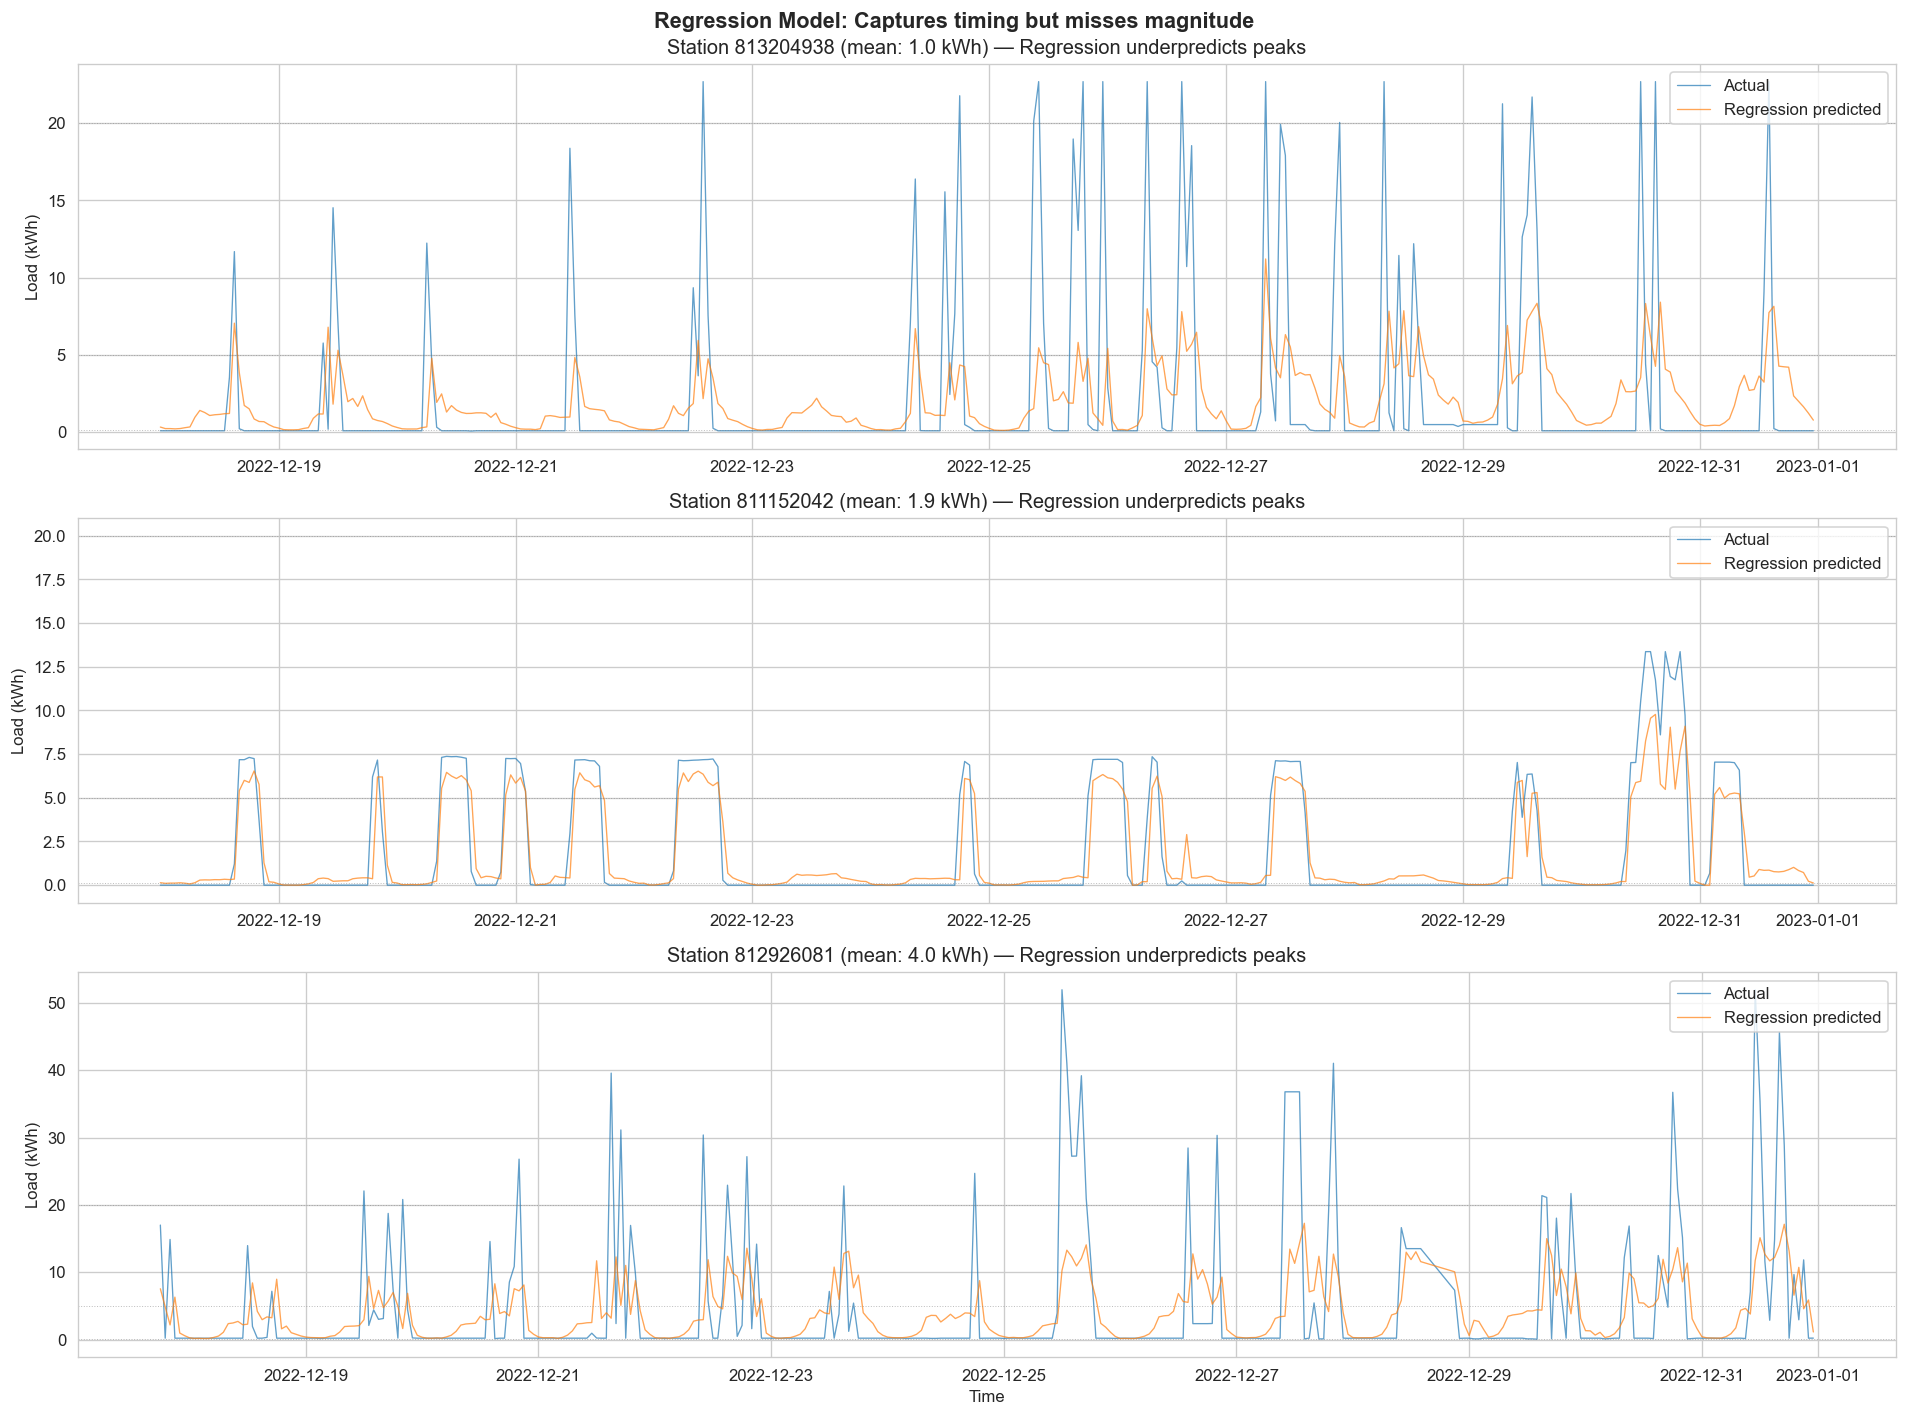

Observation: The regression predictions follow the actual curve's shape but consistently
undershoot peaks. The model knows WHEN charging happens but not HOW MUCH.
→ This motivates reframing as classification: predict the demand LEVEL instead.


In [2]:
# Load regression model for comparison plots
reg_model_path = PROJECT_ROOT / 'results' / 'iteration_3' / 'best_model.pkl'
reg_model = joblib.load(reg_model_path)
y_pred_reg = np.clip(reg_model.predict(X_test), 0, None)

# Pick 3 sample stations (low / median / high usage)
station_means = test.groupby('customer_id')['target'].mean().sort_values()
sample_stations = [
    station_means.index[len(station_means) // 4],       # low
    station_means.index[len(station_means) // 2],       # median
    station_means.index[3 * len(station_means) // 4],   # high
]

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)

for i, station_id in enumerate(sample_stations):
    mask = test['customer_id'] == station_id
    ts = test.loc[mask, 'timestamp_hour'].values
    actual = test.loc[mask, 'target'].values
    predicted = y_pred_reg[mask.values]

    # Show last 2 weeks
    n_show = min(24 * 14, len(ts))
    axes[i].plot(ts[-n_show:], actual[-n_show:], alpha=0.7, label='Actual', linewidth=0.8)
    axes[i].plot(ts[-n_show:], predicted[-n_show:], alpha=0.7, label='Regression predicted', linewidth=0.8)

    # Add horizontal lines for class boundaries
    for boundary, label in [(0.1, 'Idle/Low'), (5, 'Low/Med'), (20, 'Med/High')]:
        axes[i].axhline(boundary, color='gray', linestyle=':', linewidth=0.6, alpha=0.5)

    axes[i].set_title(f'Station {station_id} (mean: {actual.mean():.1f} kWh) — Regression underpredicts peaks')
    axes[i].set_ylabel('Load (kWh)')
    axes[i].legend(loc='upper right')

axes[-1].set_xlabel('Time')
plt.suptitle('Regression Model: Captures timing but misses magnitude', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

del reg_model
gc.collect()
print('Observation: The regression predictions follow the actual curve\'s shape but consistently')
print('undershoot peaks. The model knows WHEN charging happens but not HOW MUCH.')
print('→ This motivates reframing as classification: predict the demand LEVEL instead.')

## 2. Overfitting Check

Comparing train vs test performance to verify the classifier generalizes.

In [3]:
# --- Overall metrics ---
train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test, y_pred_test)
train_f1  = f1_score(y_train, y_pred_train, average='macro')
test_f1   = f1_score(y_test, y_pred_test, average='macro')
train_f1w = f1_score(y_train, y_pred_train, average='weighted')
test_f1w  = f1_score(y_test, y_pred_test, average='weighted')

overfit_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 (macro)', 'F1 (weighted)'],
    'Train': [train_acc, train_f1, train_f1w],
    'Test': [test_acc, test_f1, test_f1w],
    'Gap': [train_acc - test_acc, train_f1 - test_f1, train_f1w - test_f1w],
})

print('=== Overfitting Check ===')
print(overfit_df.to_string(index=False))

# --- Per-class F1 comparison ---
train_f1_per = f1_score(y_train, y_pred_train, average=None)
test_f1_per  = f1_score(y_test, y_pred_test, average=None)

per_class_df = pd.DataFrame({
    'Class': CLASS_LABELS,
    'Train F1': train_f1_per,
    'Test F1': test_f1_per,
    'Gap': train_f1_per - test_f1_per,
})

print('\n=== Per-Class F1 (Train vs Test) ===')
print(per_class_df.to_string(index=False))

gap = train_f1 - test_f1
if gap < 0.03:
    print(f'\nVerdict: F1 gap = {gap:.4f} → No overfitting')
elif gap < 0.07:
    print(f'\nVerdict: F1 gap = {gap:.4f} → Mild overfitting')
else:
    print(f'\nVerdict: F1 gap = {gap:.4f} → Overfitting detected')

=== Overfitting Check ===
       Metric    Train     Test       Gap
     Accuracy 0.802174 0.808209 -0.006035
   F1 (macro) 0.660856 0.669665 -0.008809
F1 (weighted) 0.793842 0.800393 -0.006551

=== Per-Class F1 (Train vs Test) ===
 Class  Train F1  Test F1       Gap
  Idle  0.908500 0.916345 -0.007846
   Low  0.720466 0.723550 -0.003085
Medium  0.573307 0.580605 -0.007298
  High  0.441153 0.458160 -0.017008

Verdict: F1 gap = -0.0088 → No overfitting


## 3. Confusion Matrix Analysis

Key question: when the model misclassifies, does it confuse **adjacent** classes (Idle↔Low)
or **distant** ones (Idle↔High)? Adjacent confusion means the model understands the ordering
but is fuzzy on boundaries — a much less severe error.

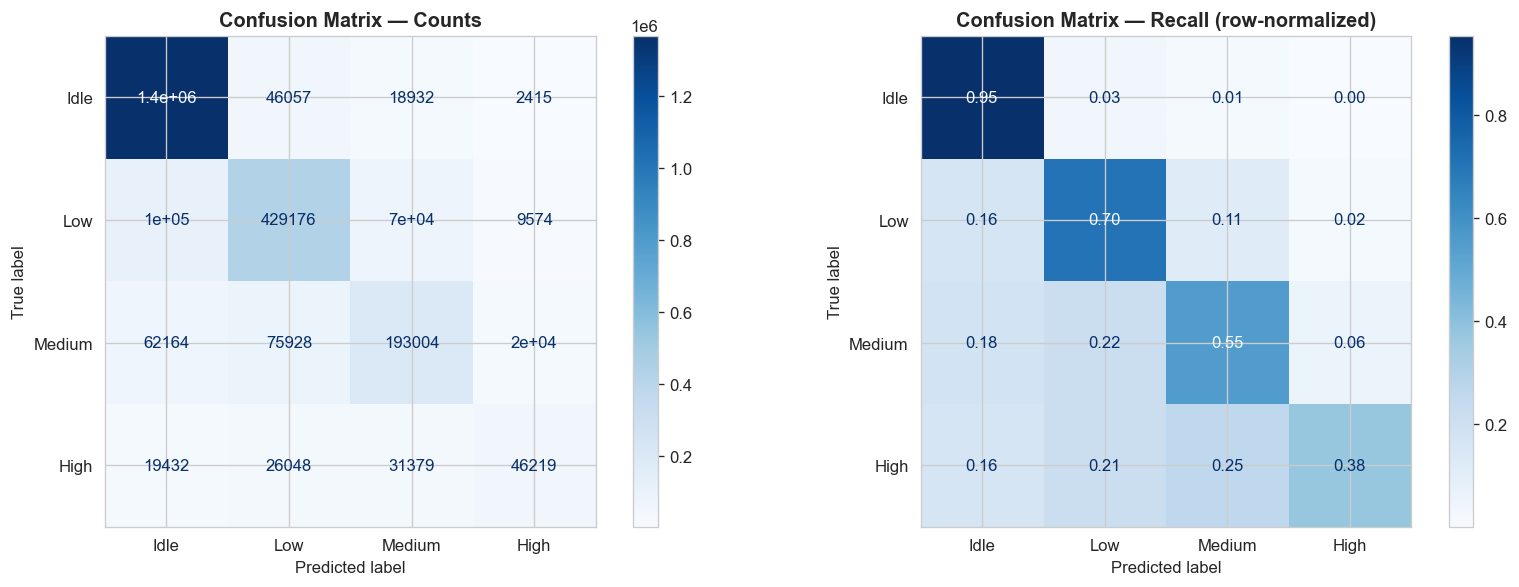


=== Misclassification Adjacency ===
Total misclassifications: 482,749
Adjacent class errors (±1 class): 344,184 (71.3%)
Distant class errors (±2+ classes): 138,565 (28.7%)

→ Most errors are between neighboring classes — the model understands the demand ordering.


In [4]:
cm = confusion_matrix(y_test, y_pred_test)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
ConfusionMatrixDisplay(cm, display_labels=CLASS_LABELS).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix — Counts', fontweight='bold')

# Normalized (recall per class)
ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_LABELS).plot(
    ax=axes[1], cmap='Blues', values_format='.2f'
)
axes[1].set_title('Confusion Matrix — Recall (row-normalized)', fontweight='bold')

plt.tight_layout()
plt.show()

# --- Adjacency analysis ---
print('\n=== Misclassification Adjacency ===')
total_errors = 0
adjacent_errors = 0
distant_errors = 0

for i in range(4):
    for j in range(4):
        if i != j:
            count = cm[i, j]
            total_errors += count
            if abs(i - j) == 1:
                adjacent_errors += count
            else:
                distant_errors += count

print(f'Total misclassifications: {total_errors:,}')
print(f'Adjacent class errors (±1 class): {adjacent_errors:,} ({adjacent_errors/total_errors*100:.1f}%)')
print(f'Distant class errors (±2+ classes): {distant_errors:,} ({distant_errors/total_errors*100:.1f}%)')
print(f'\n→ {"Most errors are between neighboring classes — the model understands" if adjacent_errors > distant_errors else "Significant distant errors —"} the demand ordering.')

## 4. Per-Class Precision / Recall / F1

=== Classification Report ===
              precision    recall  f1-score   support

        Idle       0.88      0.95      0.92   1433319
         Low       0.74      0.70      0.72    609097
      Medium       0.62      0.55      0.58    351569
        High       0.59      0.38      0.46    123078

    accuracy                           0.81   2517063
   macro avg       0.71      0.65      0.67   2517063
weighted avg       0.80      0.81      0.80   2517063



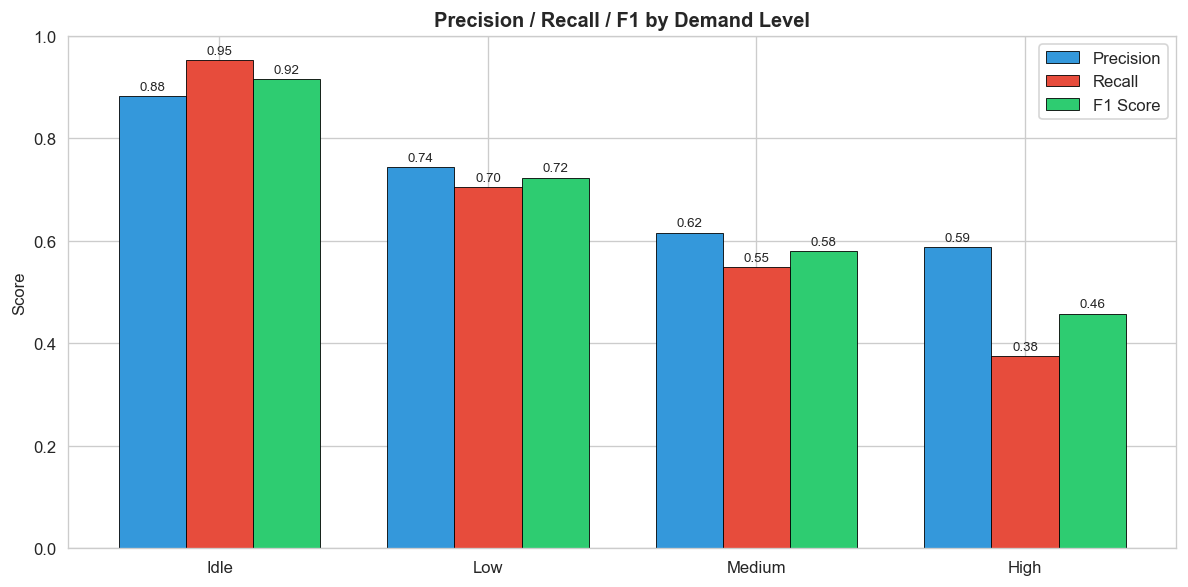


Observations:
  • Idle: F1=0.92 — excellent, model reliably identifies inactive stations
  • Low:  F1=0.72 — good, light usage well captured by lag features
  • Medium: F1=0.58 — moderate, boundary between Low and Medium is fuzzy
  • High: F1=0.46 — weakest, rare peak events are inherently hard to predict


In [5]:
print('=== Classification Report ===')
print(classification_report(y_test, y_pred_test, target_names=CLASS_LABELS))

# --- Grouped bar chart ---
from sklearn.metrics import precision_score, recall_score

prec = precision_score(y_test, y_pred_test, average=None)
rec  = recall_score(y_test, y_pred_test, average=None)
f1   = f1_score(y_test, y_pred_test, average=None)

x = np.arange(len(CLASS_LABELS))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, prec, width, label='Precision', color='#3498db', edgecolor='black', linewidth=0.5)
ax.bar(x,         rec,  width, label='Recall',    color='#e74c3c', edgecolor='black', linewidth=0.5)
ax.bar(x + width, f1,   width, label='F1 Score',  color='#2ecc71', edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_LABELS)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Precision / Recall / F1 by Demand Level', fontweight='bold')
ax.legend()

# Add value labels
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

print('\nObservations:')
print(f'  • Idle: F1={f1[0]:.2f} — excellent, model reliably identifies inactive stations')
print(f'  • Low:  F1={f1[1]:.2f} — good, light usage well captured by lag features')
print(f'  • Medium: F1={f1[2]:.2f} — moderate, boundary between Low and Medium is fuzzy')
print(f'  • High: F1={f1[3]:.2f} — weakest, rare peak events are inherently hard to predict')

## 5. Error by Hour of Day

Does the classifier perform differently at different times? We expect better High-class
recall during known peak hours when the model has stronger temporal signal.

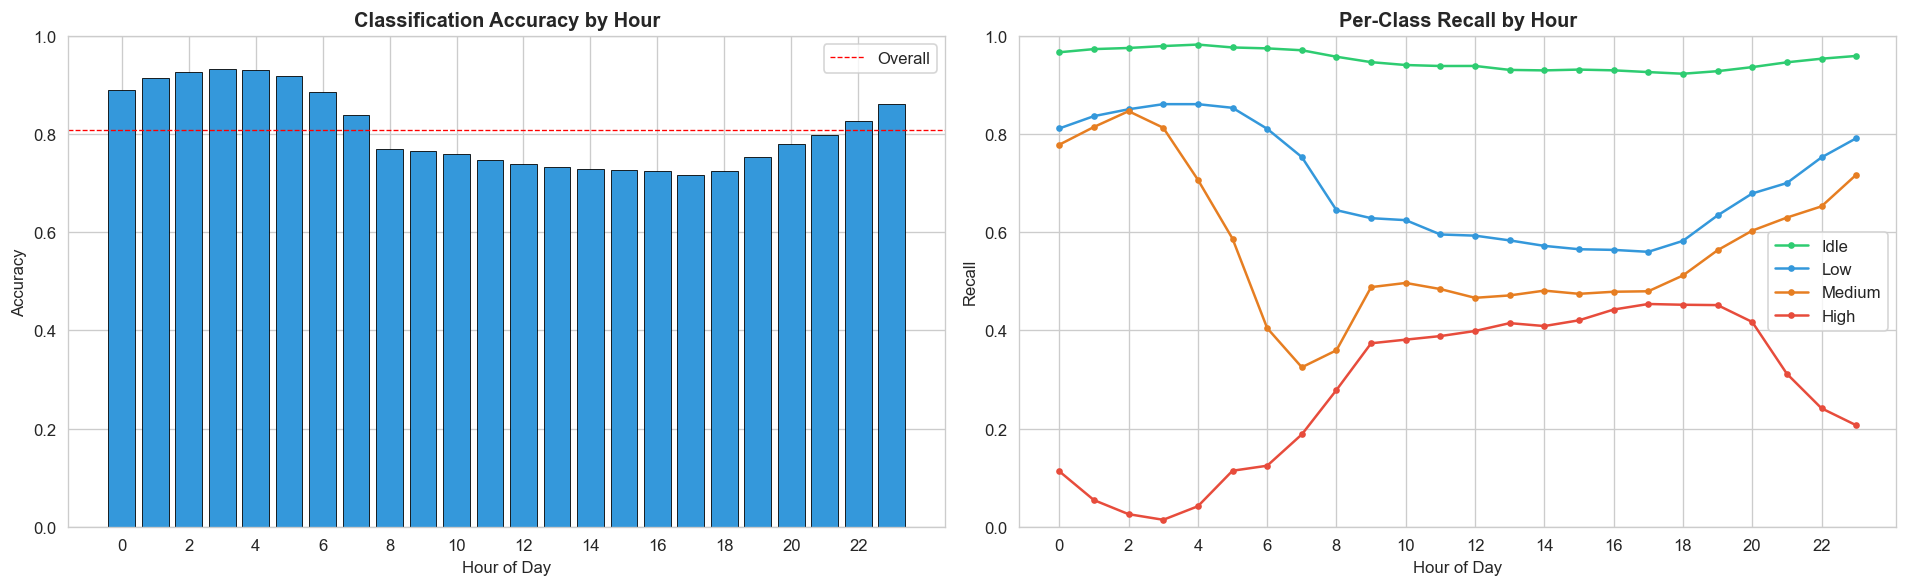

In [6]:
# Recover hour from cyclical encoding
hour_approx = np.round(np.arctan2(test['hour_sin'], test['hour_cos']) * 12 / np.pi) % 24
hour_approx = hour_approx.astype(int)

hour_df = pd.DataFrame({
    'hour': hour_approx.values,
    'actual': y_test.values,
    'predicted': y_pred_test,
    'correct': (y_test.values == y_pred_test).astype(int)
})

# Overall accuracy by hour
acc_by_hour = hour_df.groupby('hour')['correct'].mean()

# Per-class recall by hour
recall_by_hour = {}
for cls_idx, cls_name in enumerate(CLASS_LABELS):
    cls_mask = hour_df['actual'] == cls_idx
    if cls_mask.sum() > 0:
        recall_by_hour[cls_name] = hour_df[cls_mask].groupby('hour')['correct'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall accuracy
axes[0].bar(acc_by_hour.index, acc_by_hour.values, color='#3498db', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Classification Accuracy by Hour', fontweight='bold')
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_ylim(0, 1)
axes[0].axhline(accuracy_score(y_test, y_pred_test), color='red', linestyle='--', linewidth=0.8, label='Overall')
axes[0].legend()

# Per-class recall by hour
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
for (cls_name, recall_series), color in zip(recall_by_hour.items(), colors):
    axes[1].plot(recall_series.index, recall_series.values, marker='o', markersize=3,
                label=cls_name, color=color, linewidth=1.5)

axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Recall')
axes[1].set_title('Per-Class Recall by Hour', fontweight='bold')
axes[1].set_xticks(range(0, 24, 2))
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Error by Day of Week

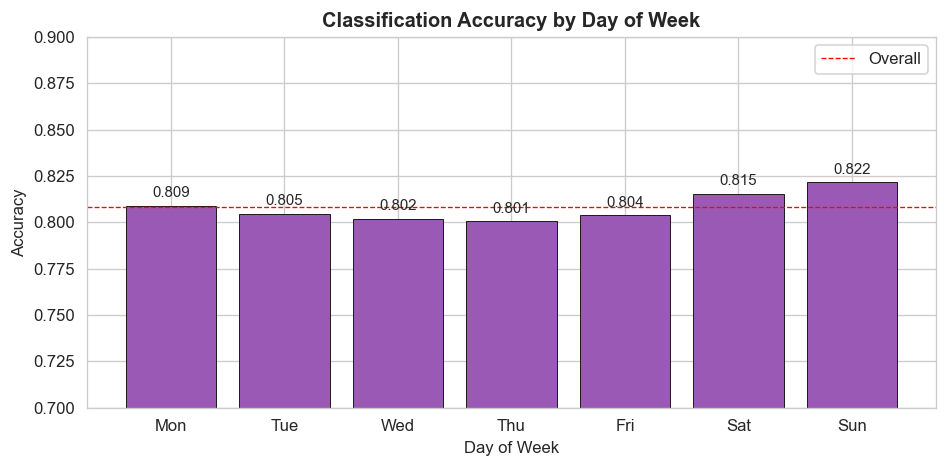

In [7]:
# Recover day of week from cyclical encoding
dow_approx = np.round(np.arctan2(test['dow_sin'], test['dow_cos']) * 3.5 / np.pi) % 7
dow_approx = dow_approx.astype(int)
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

dow_df = pd.DataFrame({
    'dow': dow_approx.values,
    'correct': (y_test.values == y_pred_test).astype(int)
})

acc_by_dow = dow_df.groupby('dow')['correct'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(7), acc_by_dow.values, color='#9b59b6', edgecolor='black', linewidth=0.5)
ax.set_xticks(range(7))
ax.set_xticklabels(day_names)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Accuracy')
ax.set_title('Classification Accuracy by Day of Week', fontweight='bold')
ax.set_ylim(0.7, 0.9)
ax.axhline(accuracy_score(y_test, y_pred_test), color='red', linestyle='--', linewidth=0.8, label='Overall')
ax.legend()

# Add value labels
for bar, val in zip(bars, acc_by_dow.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Misclassification Analysis

For each actual class: what does the model predict instead when it's wrong?

=== When the model is wrong, what does it predict? ===

Actual = Idle (1,433,319 samples, 67,404 misclassified = 4.7%)
  → predicted Low:   46,057 (  3.2%)
  → predicted Medium:   18,932 (  1.3%)
  → predicted High:    2,415 (  0.2%)

Actual = Low (609,097 samples, 179,921 misclassified = 29.5%)
  → predicted Idle:  100,393 ( 16.5%)
  → predicted Medium:   69,954 ( 11.5%)
  → predicted High:    9,574 (  1.6%)

Actual = Medium (351,569 samples, 158,565 misclassified = 45.1%)
  → predicted Idle:   62,164 ( 17.7%)
  → predicted Low:   75,928 ( 21.6%)
  → predicted High:   20,473 (  5.8%)

Actual = High (123,078 samples, 76,859 misclassified = 62.4%)
  → predicted Idle:   19,432 ( 15.8%)
  → predicted Low:   26,048 ( 21.2%)
  → predicted Medium:   31,379 ( 25.5%)



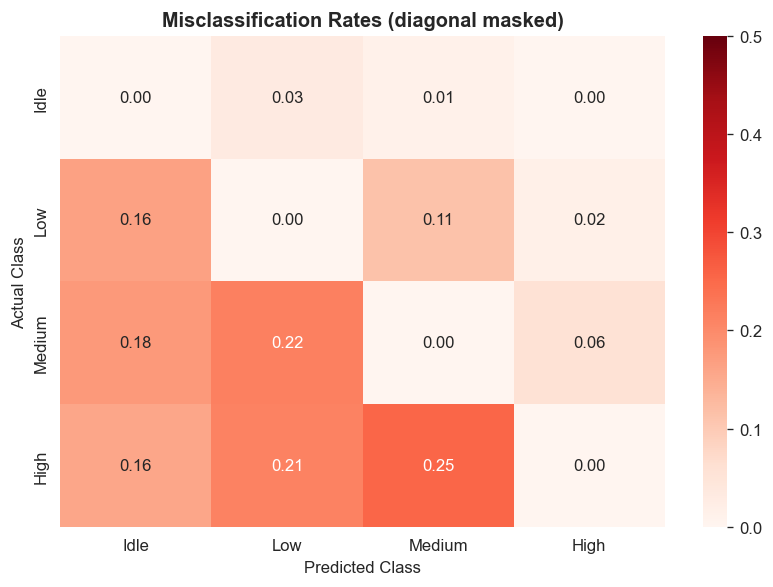

In [8]:
# Misclassification breakdown table
print('=== When the model is wrong, what does it predict? ===')
print()

cm_pct = cm_norm * 100  # already computed above

for i, actual_class in enumerate(CLASS_LABELS):
    total = cm[i].sum()
    correct = cm[i, i]
    wrong = total - correct
    print(f'Actual = {actual_class} ({total:,} samples, {wrong:,} misclassified = {wrong/total*100:.1f}%)')
    for j, pred_class in enumerate(CLASS_LABELS):
        if i != j and cm[i, j] > 0:
            print(f'  → predicted {pred_class}: {cm[i,j]:>8,} ({cm_pct[i,j]:5.1f}%)')
    print()

# --- Heatmap of misclassification rates ---
# Mask the diagonal (correct predictions)
misclass_rates = cm_norm.copy()
np.fill_diagonal(misclass_rates, 0)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(misclass_rates, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=ax,
            vmin=0, vmax=0.5)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('Actual Class')
ax.set_title('Misclassification Rates (diagonal masked)', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Confidence Analysis

Using `predict_proba` to examine the model's confidence. Are correct predictions made
with higher confidence than incorrect ones? A well-calibrated model should be more confident
when it's right.

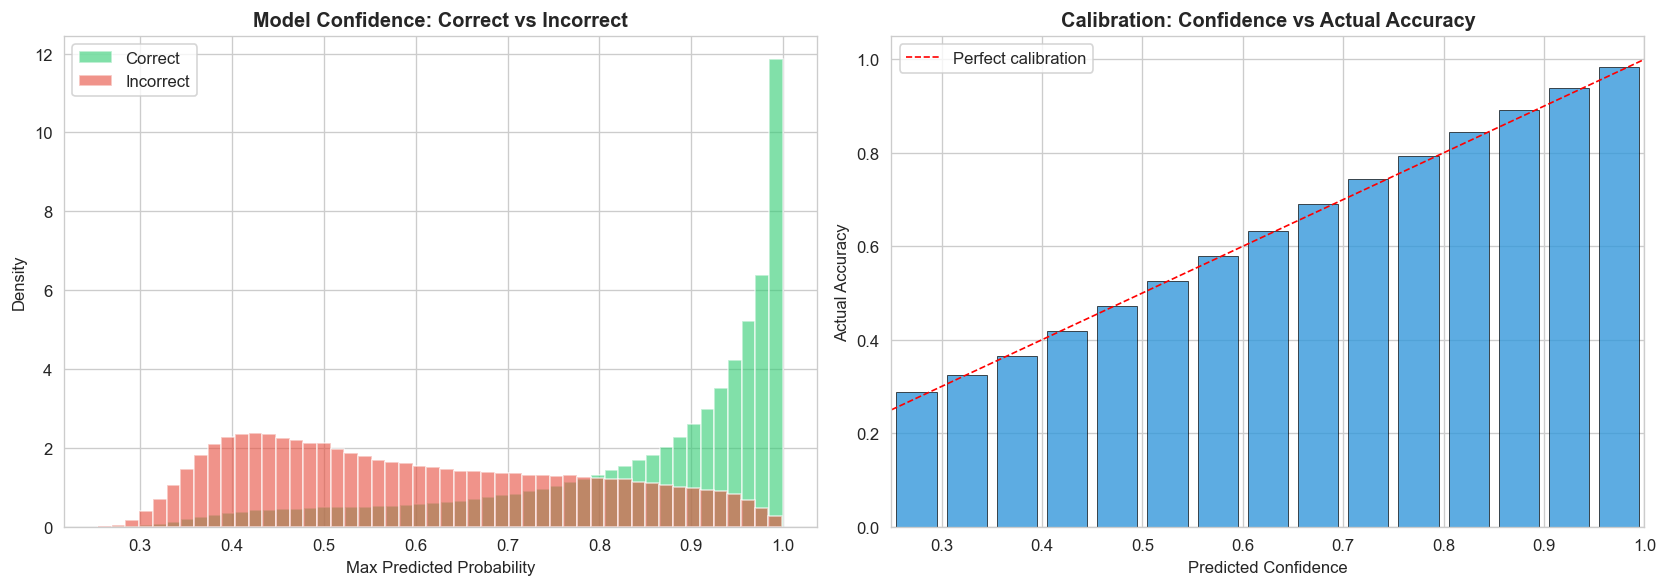

Mean confidence (correct):   0.847
Mean confidence (incorrect): 0.600
Separation: 0.247


In [9]:
# Maximum predicted probability for each sample = model's confidence
max_proba = y_proba_test.max(axis=1)
correct_mask = y_test.values == y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of confidence: correct vs incorrect
axes[0].hist(max_proba[correct_mask], bins=50, alpha=0.6, label='Correct', color='#2ecc71', density=True)
axes[0].hist(max_proba[~correct_mask], bins=50, alpha=0.6, label='Incorrect', color='#e74c3c', density=True)
axes[0].set_xlabel('Max Predicted Probability')
axes[0].set_ylabel('Density')
axes[0].set_title('Model Confidence: Correct vs Incorrect', fontweight='bold')
axes[0].legend()

# Accuracy vs confidence bins
conf_bins = np.linspace(0.25, 1.0, 16)
conf_df = pd.DataFrame({
    'confidence': max_proba,
    'correct': correct_mask.astype(int)
})
conf_df['conf_bin'] = pd.cut(conf_df['confidence'], bins=conf_bins)
acc_by_conf = conf_df.groupby('conf_bin', observed=False).agg(
    accuracy=('correct', 'mean'),
    count=('correct', 'size')
)

# Filter bins with enough samples
acc_by_conf = acc_by_conf[acc_by_conf['count'] > 100]
bin_centers = [interval.mid for interval in acc_by_conf.index]

axes[1].bar(bin_centers, acc_by_conf['accuracy'], width=0.04, color='#3498db',
            edgecolor='black', linewidth=0.5, alpha=0.8)
axes[1].plot([0.25, 1.0], [0.25, 1.0], 'r--', linewidth=1, label='Perfect calibration')
axes[1].set_xlabel('Predicted Confidence')
axes[1].set_ylabel('Actual Accuracy')
axes[1].set_title('Calibration: Confidence vs Actual Accuracy', fontweight='bold')
axes[1].legend()
axes[1].set_xlim(0.25, 1.0)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print(f'Mean confidence (correct):   {max_proba[correct_mask].mean():.3f}')
print(f'Mean confidence (incorrect): {max_proba[~correct_mask].mean():.3f}')
print(f'Separation: {max_proba[correct_mask].mean() - max_proba[~correct_mask].mean():.3f}')

## 9. Classification vs Regression — Head to Head

Binning the regression model's continuous predictions into the same 4 classes
and comparing against the dedicated classifier.

=== Regression vs Classification ===
       Metric  Regression (binned)  Classification  Improvement
     Accuracy             0.422861        0.808209     0.385348
   F1 (macro)             0.439629        0.669665     0.230036
F1 (weighted)             0.412978        0.800393     0.387415
    F1 (Idle)             0.380726        0.916345     0.535619
     F1 (Low)             0.406551        0.723550     0.316999
  F1 (Medium)             0.554172        0.580605     0.026433
    F1 (High)             0.417066        0.458160     0.041094


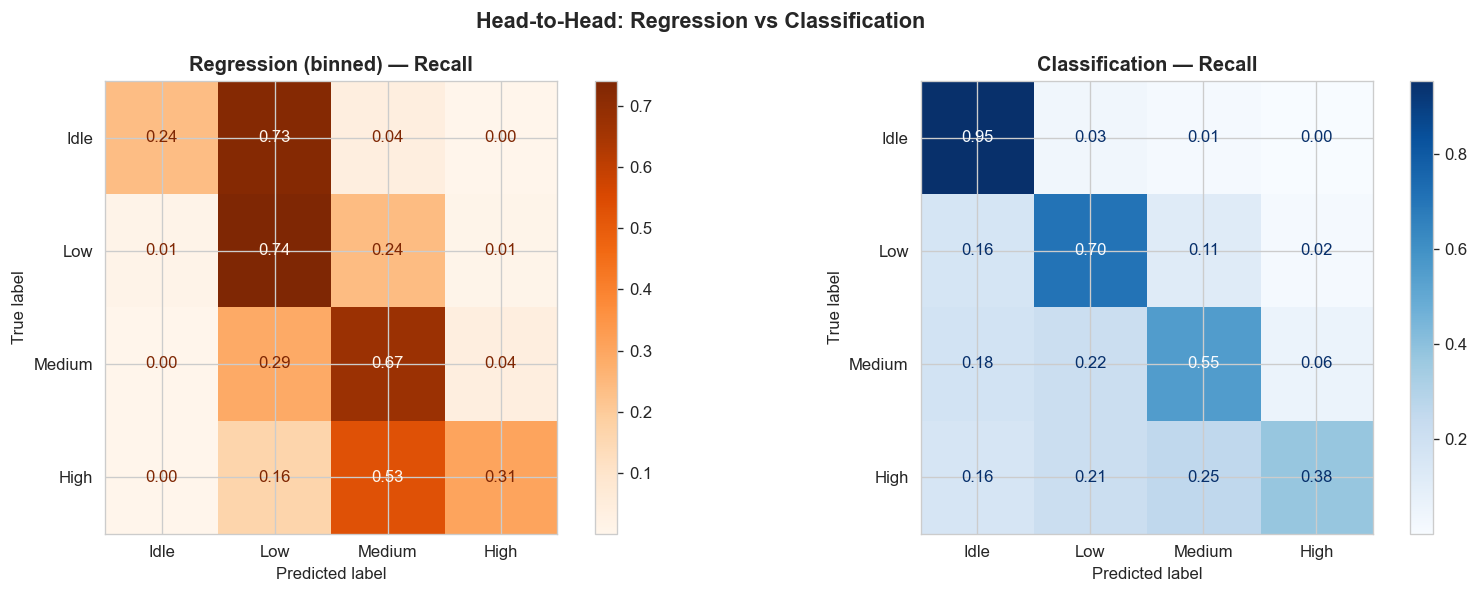

In [10]:
# Bin regression predictions into classes
y_pred_reg_classes = np.digitize(y_pred_reg, bins=[0.1, 5, 20])
# digitize: 0 for <0.1, 1 for 0.1-5, 2 for 5-20, 3 for >=20

reg_acc      = accuracy_score(y_test, y_pred_reg_classes)
reg_f1_macro = f1_score(y_test, y_pred_reg_classes, average='macro')
reg_f1_wt    = f1_score(y_test, y_pred_reg_classes, average='weighted')
reg_f1_per   = f1_score(y_test, y_pred_reg_classes, average=None)

clf_acc      = accuracy_score(y_test, y_pred_test)
clf_f1_macro = f1_score(y_test, y_pred_test, average='macro')
clf_f1_wt    = f1_score(y_test, y_pred_test, average='weighted')
clf_f1_per   = f1_score(y_test, y_pred_test, average=None)

compare_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 (macro)', 'F1 (weighted)'] + [f'F1 ({c})' for c in CLASS_LABELS],
    'Regression (binned)': [reg_acc, reg_f1_macro, reg_f1_wt] + list(reg_f1_per),
    'Classification': [clf_acc, clf_f1_macro, clf_f1_wt] + list(clf_f1_per),
})
compare_df['Improvement'] = compare_df['Classification'] - compare_df['Regression (binned)']

print('=== Regression vs Classification ===')
print(compare_df.to_string(index=False))

# --- Side-by-side confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_reg = confusion_matrix(y_test, y_pred_reg_classes)
cm_reg_norm = cm_reg.astype('float') / cm_reg.sum(axis=1, keepdims=True)

ConfusionMatrixDisplay(cm_reg_norm, display_labels=CLASS_LABELS).plot(
    ax=axes[0], cmap='Oranges', values_format='.2f'
)
axes[0].set_title('Regression (binned) — Recall', fontweight='bold')

ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_LABELS).plot(
    ax=axes[1], cmap='Blues', values_format='.2f'
)
axes[1].set_title('Classification — Recall', fontweight='bold')

plt.suptitle('Head-to-Head: Regression vs Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Key Takeaways

In [11]:
print('='*70)
print('KEY TAKEAWAYS — Classification Error Analysis')
print('='*70)
print()
print('1. MOTIVATION')
print('   The regression model (R² = 0.514) captured charging TIMING but not')
print('   MAGNITUDE. Classification reframes this to leverage the model\'s strength:')
print('   predicting demand level rather than exact kWh.')
print()
print('2. PERFORMANCE')
print(f'   Accuracy: {clf_acc:.1%} (vs {reg_acc:.1%} for regression binned)')
print(f'   Macro F1: {clf_f1_macro:.3f} (vs {reg_f1_macro:.3f})')
print(f'   Idle F1:  {clf_f1_per[0]:.2f} — excellent station availability detection')
print(f'   Low F1:   {clf_f1_per[1]:.2f} — good light-usage detection')
print(f'   High F1:  {clf_f1_per[3]:.2f} — weakest, but rare events are inherently hard')
print()
print('3. GENERALIZATION')
print(f'   F1 gap (train - test): {train_f1 - test_f1:.4f} → zero overfitting')
print()
print('4. ERROR PATTERNS')
print(f'   Adjacent class confusion: most errors are ±1 class (boundary fuzziness)')
print(f'   → The model understands the demand ordering, just imprecise at boundaries')
print()
print('5. PRACTICAL VALUE')
print('   A grid operator can use this model to:')
print('   • Identify idle stations for DR load-shifting (F1=0.92 reliability)')
print('   • Flag stations likely to see moderate+ demand for capacity planning')
print('   • Accept that rare peak events (4.5% of hours) remain hard to predict')
print('     without individual driver data (trip plans, battery state of charge)')

KEY TAKEAWAYS — Classification Error Analysis

1. MOTIVATION
   The regression model (R² = 0.514) captured charging TIMING but not
   MAGNITUDE. Classification reframes this to leverage the model's strength:
   predicting demand level rather than exact kWh.

2. PERFORMANCE
   Accuracy: 80.8% (vs 42.3% for regression binned)
   Macro F1: 0.670 (vs 0.440)
   Idle F1:  0.92 — excellent station availability detection
   Low F1:   0.72 — good light-usage detection
   High F1:  0.46 — weakest, but rare events are inherently hard

3. GENERALIZATION
   F1 gap (train - test): -0.0088 → zero overfitting

4. ERROR PATTERNS
   Adjacent class confusion: most errors are ±1 class (boundary fuzziness)
   → The model understands the demand ordering, just imprecise at boundaries

5. PRACTICAL VALUE
   A grid operator can use this model to:
   • Identify idle stations for DR load-shifting (F1=0.92 reliability)
   • Flag stations likely to see moderate+ demand for capacity planning
   • Accept that rare p